In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations

from sklearn.preprocessing import RobustScaler

import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from itertools import product
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge, Lasso, BayesianRidge
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
import joblib

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from scipy.stats import loguniform, randint, uniform
from sklearn.feature_selection import f_regression

In [30]:
data=pd.read_excel("data - copie.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','Ra','Desnity','VED','LED','PED']
X_selected=['p','v','h','t']
X = data[X_selected].values
y = data[['Ra']].values

In [31]:
data2=pd.read_excel('synthetic_data_gmm_1400.xlsx')
data2 = data2.replace({',': '.'}, regex=True)

data2.columns=['p','v','h','t','Ra']

X2 = data2[X_selected].values
y2 = data2[['Ra']].values

In [32]:
X_combined = np.vstack((X, X2))
y_combined = np.vstack((y, y2))
data_combined = pd.DataFrame(X_combined, columns=X_selected)
data_combined['Ra'] = y_combined

In [33]:
data_combined.describe()

,p,v,h,t,Ra
count,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000
mean,188.593354,765.215142,96.250481,34.108958,10.057232
std,83.540069,248.739651,26.900873,12.729831,5.116998
min,44.336022,71.597240,36.687026,16.385326,1.101585
25%,139.887834,590.534152,79.968547,22.954094,6.428591
50%,166.959155,769.357443,91.346862,30.002083,9.553043
75%,239.691081,962.694853,112.416213,42.663418,11.702779
max,393.167844,1555.213650,200.054491,68.824275,32.248786


In [34]:
def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5


In [35]:
data_extended = data_combined.copy()

data_extended['I(p^2)'] = data_extended['p']**2
data_extended['I(v^2)'] = data_extended['v']**2
data_extended['I(h^2)'] = data_extended['h']**2
data_extended['I(t^2)'] = data_extended['t']**2


data_extended['p:v'] = data_extended['p'] * data_extended['v']
data_extended['p:h'] = data_extended['p'] * data_extended['h']
data_extended['p:t'] = data_extended['p'] * data_extended['t']
data_extended['v:h'] = data_extended['v'] * data_extended['h']
data_extended['v:t'] = data_extended['v'] * data_extended['t']
data_extended['h:t'] = data_extended['h'] * data_extended['t']
data_extended['p:v:h'] = data_extended['p'] * data_extended['v'] * data_extended['h']
data_extended['p:v:t'] = data_extended['p'] * data_extended['v'] * data_extended['t']
data_extended['p:h:t'] = data_extended['p'] * data_extended['h'] * data_extended['t']
data_extended['v:h:t'] = data_extended['v'] * data_extended['h'] * data_extended['t']
data_extended['p:v:h:t'] = data_extended['p'] * data_extended['v'] * data_extended['h'] * data_extended['t']

variables = ['p', 'v', 'h', 't']

for var1, var2 in combinations(variables, 2):
    data_extended[f'I({var1}^2 * {var2})'] = (data_extended[var1]**2) * data_extended[var2]

for var1, var2, var3 in combinations(variables, 3):
    data_extended[f'I({var1}^2 * {var2} * {var3}^2)'] = (data_extended[var1]**2) * (data_extended[var2]) * (data_extended[var3]**2)

data_extended[f'I(p^2 * v^2 * h^2 * t^2)'] = (data_extended['p']**2) * (data_extended['v']**2) * (data_extended['h']**2) * (data_extended['t']**2)

data_extended['I(p^2 * v * h)'] = (data_extended['p']**2) * data_extended['v'] * (data_extended['h'])
data_extended['I(p * v^2 * h)'] = data_extended['p'] * (data_extended['v']) * (data_extended['h']**2)
data_extended['I(p^2 * v * h * t)'] = (data_extended['p']**2) * data_extended['v'] * data_extended['h'] * (data_extended['t'])


data_extended['I(sqrt(h)'] = np.sqrt(data_extended['h'])
data_extended['I(sqrt(v)'] = np.sqrt(data_extended['v'])
data_extended['I(sqrt(p)'] = np.sqrt(data_extended['p'])
data_extended['I(sqrt(t)'] = np.sqrt(data_extended['t'])

data_extended['I(sqrt(p) * v)'] = np.sqrt(data_extended['p']) * data_extended['v']
data_extended['I(sqrt(p) * h)'] = np.sqrt(data_extended['p']) * data_extended['h']
data_extended['I(sqrt(p) * t)'] = np.sqrt(data_extended['p']) * data_extended['t']

data_extended['I(sqrt(v) * p)'] = np.sqrt(data_extended['v']) * data_extended['p']
data_extended['I(sqrt(v) * h)'] = np.sqrt(data_extended['v']) * data_extended['h']
data_extended['I(sqrt(v) * t)'] = np.sqrt(data_extended['v']) * data_extended['t']

data_extended['I(sqrt(h) * p)'] = np.sqrt(data_extended['h']) * data_extended['p']
data_extended['I(sqrt(h) * v)'] = np.sqrt(data_extended['h']) * data_extended['v']
data_extended['I(sqrt(h) * t)'] = np.sqrt(data_extended['h']) * data_extended['t']

data_extended['I(sqrt(t) * p)'] = np.sqrt(data_extended['t']) * data_extended['p']
data_extended['I(sqrt(t) * v)'] = np.sqrt(data_extended['t']) * data_extended['v']
data_extended['I(sqrt(t) * h)'] = np.sqrt(data_extended['t']) * data_extended['h']

data_extended['I(p * sqrt(v))'] = data_extended['p'] * np.sqrt(data_extended['v'])
data_extended['I(sqrt(h) * t^2)'] = np.sqrt(data_extended['h']) * (data_extended['t']**2)
data_extended['I(p * h * sqrt(t))'] = data_extended['p'] * data_extended['h'] * np.sqrt(data_extended['t'])

data_extended['I(log(p) * v)'] = np.log(data_extended['p'] + 1e-6) * data_extended['v']
data_extended['I(log(p) * t)'] = np.log(data_extended['p'] + 1e-6) * data_extended['t']
data_extended['I(log(p) * h)'] = np.log(data_extended['p'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * p)'] = np.log(data_extended['v'] + 1e-6) * data_extended['p']
data_extended['I(log(v) * h)'] = np.log(data_extended['v'] + 1e-6) * data_extended['h']
data_extended['I(log(v) * t)'] = np.log(data_extended['v'] + 1e-6) * data_extended['t']
data_extended['I(log(h) * p)'] = np.log(data_extended['h'] + 1e-6) * data_extended['p']
data_extended['I(log(h) * v)'] = np.log(data_extended['h'] + 1e-6) * data_extended['v']
data_extended['I(log(h) * t)'] = np.log(data_extended['h'] + 1e-6) * data_extended['t']
data_extended['I(log(t) * p)'] = np.log(data_extended['t'] + 1e-6) * data_extended['p']
data_extended['I(log(t) * h)'] = np.log(data_extended['t'] + 1e-6) * data_extended['h']
data_extended['I(log(t) * v)'] = np.log(data_extended['t'] + 1e-6) * data_extended['v']
for var in variables:
    data_extended[f'I({var}^-1)'] = 1 / (data_extended[var] + 1e-6)


for var1 in variables:
    for var2 in variables:
        if var1 != var2:
            data_extended[f'I({var1} * {var2}^-1)'] = data_extended[var1] / (data_extended[var2] + 1e-6)


for r in range(2, len(variables) + 1):
    for combo in combinations(variables, r):
        
        col_name = 'I(' + ' * '.join([f'{v}^-1' for v in combo]) + ')'
        inv_product = np.ones(len(data_extended))
        for v in combo:
            inv_product *= 1 / (data_extended[v] + 1e-6)
        data_extended[col_name] = inv_product

In [36]:
X = data_extended.drop(columns=['Ra', 'density', 'VED', 'LED', 'PED'], errors='ignore')
scaler = RobustScaler()
X_standardized = scaler.fit_transform(X)

X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

y = data_combined['Ra']
f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({'Variable': X_standardized.columns, 'F-Score': f_scores, 'p-value': p_values})
significant_vars = anova_results[anova_results['p-value'] < 0.05]
significant_vars = significant_vars.sort_values(by='F-Score', ascending=False)
print(significant_vars)

                 Variable     F-Score        p-value
24             I(h^2 * t)  642.140573  1.245877e-118
13                    h:t  525.121747  3.457665e-100
48         I(sqrt(t) * h)  441.720549   2.186999e-86
45         I(sqrt(h) * t)  389.112209   2.245522e-77
50       I(sqrt(h) * t^2)  377.500694   2.365285e-75
..                    ...         ...            ...
8                     p:v   12.486357   4.220932e-04
86  I(p^-1 * v^-1 * h^-1)    9.080637   2.625632e-03
52          I(log(p) * v)    8.761339   3.124046e-03
63          I(log(t) * v)    5.649933   1.757809e-02
44         I(sqrt(h) * v)    4.558414   3.291545e-02

[83 rows x 3 columns]


In [37]:
from sklearn.feature_selection import mutual_info_regression


X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data_combined['Ra']

mi_scores = mutual_info_regression(X_standardized, y)

mi_results = pd.DataFrame({'Variable': X_standardized.columns, 'MI Score': mi_scores})

mi_results = mi_results.sort_values(by='MI Score', ascending=False)

print("\nScores d'Information Mutuelle :")
print(mi_results)

top_features = mi_results.head(10)['Variable']
print("\nTop 10 des variables les plus significatives selon l'information mutuelle :")
print(top_features)

X_selected = X[top_features]



Scores d'Information Mutuelle :
            Variable  MI Score
53     I(log(p) * t)  0.655269
50  I(sqrt(h) * t^2)  0.602002
60     I(log(h) * t)  0.599761
57     I(log(v) * t)  0.546580
45    I(sqrt(h) * t)  0.508085
..               ...       ...
49    I(p * sqrt(v))  0.283779
52     I(log(p) * v)  0.278343
72       I(v * h^-1)  0.263441
8                p:v  0.252884
37    I(sqrt(p) * v)  0.250152

[91 rows x 2 columns]

Top 10 des variables les plus significatives selon l'information mutuelle :
53       I(log(p) * t)
50    I(sqrt(h) * t^2)
60       I(log(h) * t)
57       I(log(v) * t)
45      I(sqrt(h) * t)
39      I(sqrt(p) * t)
16               p:h:t
7               I(t^2)
13                 h:t
3                    t
Name: Variable, dtype: object


In [38]:
from sklearn.feature_selection import f_regression, mutual_info_regression

X = data_extended.drop(columns=['Ra'], errors='ignore')

scaler = RobustScaler()
X_standardized = scaler.fit_transform(X)
X_standardized = pd.DataFrame(X_standardized, columns=X.columns)
y = data_combined['Ra']

f_scores, p_values = f_regression(X_standardized, y)
anova_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'F-Score': f_scores,
    'p-value': p_values
})

anova_significant = anova_results[anova_results['p-value'] < 0.05]['Variable'].tolist()

mi_scores = mutual_info_regression(X_standardized, y)
mi_results = pd.DataFrame({
    'Variable': X_standardized.columns,
    'MI-Score': mi_scores
})

threshold = 0.1
mi_significant = mi_results[mi_results['MI-Score'] > threshold]['Variable'].tolist()

selected_vars = list(set(anova_significant) & set(mi_significant))

X_selected_vars = X[selected_vars]

print("Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :")
print(selected_vars)


Variables sélectionnées (communes entre ANOVA et Information Mutuelle) :
['I(p^2)', 'I(v * h^-1)', 'I(sqrt(p)', 'I(log(p) * h)', 'I(sqrt(h)', 'I(p * v^-1)', 'I(h^-1)', 'h', 'I(t^2)', 'I(v^-1)', 'I(p^-1 * h^-1)', 'I(p^-1 * t^-1)', 'p:h', 'I(log(h) * t)', 'I(h^2)', 'I(sqrt(t) * h)', 'I(p^2 * v * t^2)', 'p:t', 'I(log(t) * h)', 'I(p^-1 * v^-1 * t^-1)', 'I(log(v) * h)', 'I(p^-1 * h^-1 * t^-1)', 'I(log(h) * v)', 'I(p^-1 * v^-1 * h^-1 * t^-1)', 'I(p^2 * v^2 * h^2 * t^2)', 'I(p^2 * v)', 'v:t', 'p:v:h', 'v:h:t', 'I(p^2 * t)', 'I(log(p) * t)', 'I(p^2 * v * h)', 'I(log(t) * p)', 'I(t * h^-1)', 'p:v:h:t', 'I(p^2 * h)', 'p', 'I(h^2 * t)', 'p:v', 'I(sqrt(v) * t)', 'I(v^2 * h * t^2)', 'I(sqrt(v) * h)', 'I(h * p^-1)', 'I(h * v^-1)', 'I(t * v^-1)', 'I(log(h) * p)', 'I(h * t^-1)', 'I(p^-1)', 'h:t', 'I(sqrt(p) * t)', 'I(p^2 * v * h^2)', 'I(sqrt(v) * p)', 'I(p^-1 * v^-1 * h^-1)', 'I(t * p^-1)', 'I(v^2)', 'I(v * t^-1)', 'I(p^2 * v * h * t)', 'I(p * v^2 * h)', 'I(log(p) * v)', 'p:v:t', 'I(sqrt(p) * h)', 'I(

In [39]:
corr_matrix = X_selected_vars.corr().abs()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]

X_filtered = X_selected_vars.drop(columns=to_drop)

print(f"Variables supprimées car trop corrélées: {to_drop}")
print(f"Nombre de variables restantes: {X_filtered.shape[1]}")

Variables supprimées car trop corrélées: ['I(sqrt(p)', 'I(sqrt(h)', 'I(h^-1)', 'h', 'I(p^-1 * t^-1)', 'p:h', 'I(log(h) * t)', 'I(h^2)', 'I(sqrt(t) * h)', 'I(p^2 * v * t^2)', 'p:t', 'I(log(t) * h)', 'I(p^-1 * v^-1 * t^-1)', 'I(log(v) * h)', 'I(p^-1 * h^-1 * t^-1)', 'I(p^-1 * v^-1 * h^-1 * t^-1)', 'I(p^2 * v^2 * h^2 * t^2)', 'I(p^2 * v)', 'v:t', 'p:v:h', 'v:h:t', 'I(p^2 * t)', 'I(log(p) * t)', 'I(p^2 * v * h)', 'I(log(t) * p)', 'p:v:h:t', 'I(p^2 * h)', 'p', 'I(h^2 * t)', 'p:v', 'I(sqrt(v) * t)', 'I(v^2 * h * t^2)', 'I(sqrt(v) * h)', 'I(h * v^-1)', 'I(t * v^-1)', 'I(log(h) * p)', 'I(h * t^-1)', 'I(p^-1)', 'h:t', 'I(sqrt(p) * t)', 'I(p^2 * v * h^2)', 'I(sqrt(v) * p)', 'I(p^-1 * v^-1 * h^-1)', 'I(v^2)', 'I(p^2 * v * h * t)', 'I(p * v^2 * h)', 'I(log(p) * v)', 'p:v:t', 'I(sqrt(p) * h)', 'I(v * p^-1)', 'I(sqrt(v)', 'I(log(v) * p)', 'I(t^-1)', 'I(p * h * sqrt(t))', 'v', 'I(sqrt(t) * p)', 'I(v^-1 * t^-1)', 'I(sqrt(h) * t^2)', 'I(log(v) * t)', 't', 'I(v^-1 * h^-1 * t^-1)', 'I(sqrt(h) * v)', 'I(s

In [40]:
X_filtered

,I(p^2),I(v * h^-1),I(log(p) * h),I(p * v^-1),I(t^2),I(v^-1),I(p^-1 * h^-1),I(log(h) * v),I(t * h^-1),I(h * p^-1),I(t * p^-1),I(v * t^-1)
0,22500.000000,3.478261,576.223060,0.375000,625.000000,0.002500,0.000058,1897.972855,0.217391,0.766667,0.166667,15.999999
1,22500.000000,6.086956,576.223060,0.214286,625.000000,0.001429,0.000058,3321.452496,0.217391,0.766667,0.166667,27.999999
2,22500.000000,8.695652,576.223060,0.150000,625.000000,0.001000,0.000058,4744.932137,0.217391,0.766667,0.166667,39.999998
3,32400.000000,3.478261,597.190038,0.450000,625.000000,0.002500,0.000048,1897.972855,0.217391,0.638889,0.138889,15.999999
4,32400.000000,6.086956,597.190038,0.257143,625.000000,0.001429,0.000048,3321.452496,0.217391,0.638889,0.138889,27.999999
...,...,...,...,...,...,...,...,...,...,...,...,...
1531,18360.403578,6.037456,640.313778,0.172062,2498.453220,0.001270,0.000057,3835.875394,0.383207,0.962633,0.368888,15.755068
1532,47966.829380,7.375814,662.282128,0.241622,2501.233662,0.001103,0.000037,4361.111559,0.406961,0.561117,0.228353,18.124122
1533,19867.295239,6.758337,610.457387,0.169060,2500.953523,0.001199,0.000058,4014.561373,0.405381,0.875225,0.354800,16.671561
1534,25036.562437,7.754302,592.561016,0.174385,2500.882152,0.001102,0.000054,4321.094597,0.427377,0.739517,0.316053,18.143935


In [41]:
X_selected=["p","v","h","t","I(p^2)",	"I(v * h^-1)",	"I(log(p) * h)",	"I(p * v^-1)",	"I(t^2)",	"I(v^-1)",	"I(p^-1 * h^-1)",	"I(log(h) * v)",	"I(t * h^-1)",	"I(h * p^-1)",	"I(t * p^-1)",	"I(v * t^-1)"]

In [42]:

X=data_extended[X_selected].values
scaler=RobustScaler()
X_scaled =scaler.fit_transform(X_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_combined, 
    test_size=0.30, 
    random_state=42,shuffle=True)
y_train_bc=box_cox_fun(y_train)
y_test_bc=box_cox_fun(y_test)

In [44]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, PReLU
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, AdamW
from tensorflow.keras.callbacks import EarlyStopping




def get_optimizer(optimizer_name, learning_rate):
    optimizers_dict = {
        'adam': Adam(learning_rate=learning_rate),
        'adamw': AdamW(learning_rate=learning_rate, weight_decay=1e-4),
        'sgd': SGD(learning_rate=learning_rate),
        'rmsprop': RMSprop(learning_rate=learning_rate),
    }
    
    if optimizer_name.lower() not in optimizers_dict:
        raise ValueError(f"Optimiseur '{optimizer_name}' non supporté ! Choisis parmi {list(optimizers_dict.keys())}")
    
    return optimizers_dict[optimizer_name.lower()]

def build_model(input_dim, optimizer_name, learning_rate):
    opt = get_optimizer(optimizer_name, learning_rate)
    
    model = Sequential([
        Dense(512, input_dim=input_dim),
        BatchNormalization(),
        PReLU(),

        Dense(256),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(128),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(64),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(32),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(16),
        BatchNormalization(),
        PReLU(),
        Dropout(0.2),

        Dense(1, activation='linear')
    ])
    
    model.compile(optimizer=opt, loss=tf.keras.losses.Huber(delta=1.0), metrics=['mae'])
    return model


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=70,
    restore_best_weights=True
)


optimizers = ['adam', 'adamw', 'rmsprop']
learning_rates = [0.001, 0.005, 0.01]
batch_sizes = [16,32]


best_score = float('inf')
best_params = {}
best_model = None
results = []


for opt_name in optimizers:
    for lr in learning_rates:
        for bs in batch_sizes:
            print(f"\n🔵 Test: optimizer={opt_name}, learning_rate={lr}, batch_size={bs}")
            
            model = build_model(X_train.shape[1], opt_name, lr)
            
            history = model.fit(
                X_train, y_train_bc,
                epochs=5000,
                batch_size=bs,
                validation_data=(X_test, y_test_bc),
                verbose=0,
                callbacks=[early_stopping]
            )
            
            preds = model.predict(X_test).squeeze()
            preds = inverse_box_cox(preds)
            
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            mae = mean_absolute_error(y_test, preds)
            r2 = r2_score(y_test, preds)
            
           
            results.append({
                'optimizer': opt_name,
                'learning_rate': lr,
                'batch_size': bs,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            })
            
           
            if rmse < best_score:
                best_score = rmse
                best_params = {'optimizer': opt_name, 'learning_rate': lr, 'batch_size': bs}
                best_model = model


results_df = pd.DataFrame(results)
print("\n📊 Résumé de tous les tests :")
print(results_df.sort_values('RMSE'))


print("\n✅ Meilleurs hyperparamètres trouvés :")
print(best_params)
print(f"RMSE: {best_score:.4f}")


y_pred_final = best_model.predict(X_test)
y_pred_final = inverse_box_cox(y_pred_final)

print("\n📈 Résultats finaux sur le test set :")
print(f"R2 : {r2_score(y_test, y_pred_final):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")



🔵 Test: optimizer=adam, learning_rate=0.001, batch_size=16
15/15 [==============================] - 0s 6ms/step

🔵 Test: optimizer=adam, learning_rate=0.001, batch_size=32
15/15 [==============================] - 0s 3ms/step

🔵 Test: optimizer=adam, learning_rate=0.005, batch_size=16
15/15 [==============================] - 0s 2ms/step

🔵 Test: optimizer=adam, learning_rate=0.005, batch_size=32
15/15 [==============================] - 1s 6ms/step

🔵 Test: optimizer=adam, learning_rate=0.01, batch_size=16
15/15 [==============================] - 0s 4ms/step

🔵 Test: optimizer=adam, learning_rate=0.01, batch_size=32
15/15 [==============================] - 0s 3ms/step

🔵 Test: optimizer=adamw, learning_rate=0.001, batch_size=16
15/15 [==============================] - 0s 3ms/step

🔵 Test: optimizer=adamw, learning_rate=0.001, batch_size=32
15/15 [==============================] - 0s 3ms/step

🔵 Test: optimizer=adamw, learning_rate=0.005, batch_size=16
15/15 [============================

In [46]:
best_model.save("models_pvht_anova_gmm1400/best_model.h5")

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, PReLU
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.optimizers import Adam, SGD, RMSprop, AdamW


def build_best_model(input_dim):
    model = Sequential([
        Dense(512, input_dim=input_dim),
        BatchNormalization(),
        PReLU(),

        Dense(256),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(128),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(64),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(32),
        BatchNormalization(),
        PReLU(),
        Dropout(0.3),

        Dense(16),
        BatchNormalization(),
        PReLU(),
        Dropout(0.2),

        Dense(1, activation='linear')
    ])

    optimizer = RMSprop(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(delta=1.0), metrics=['mae'])
    return model


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=70,
    restore_best_weights=True
)


model = build_best_model(X_train.shape[1])

history = model.fit(
    X_train, y_train_bc,
    epochs=5000,
    batch_size=32,
    validation_data=(X_test, y_test_bc),
    verbose=1,
    callbacks=[early_stopping]
)


y_pred_final = model.predict(X_test)
y_pred_final = inverse_box_cox(y_pred_final)


print("\n📈 Résultats finaux sur le test set :")
print(f"R2 : {r2_score(y_test, y_pred_final):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_final)):.4f}")


Epoch 1/5000
34/34 [==============================] - 3s 25ms/step - loss: 2.9659 - mae: 3.4562 - val_loss: 3.5234 - val_mae: 4.0234
Epoch 2/5000
34/34 [==============================] - 1s 19ms/step - loss: 2.4357 - mae: 2.9210 - val_loss: 3.2052 - val_mae: 3.7049
Epoch 3/5000
34/34 [==============================] - 1s 15ms/step - loss: 1.9864 - mae: 2.4573 - val_loss: 2.7733 - val_mae: 3.2702
Epoch 4/5000
34/34 [==============================] - 0s 12ms/step - loss: 1.5635 - mae: 2.0165 - val_loss: 2.3572 - val_mae: 2.8500
Epoch 5/5000
34/34 [==============================] - 0s 12ms/step - loss: 1.2861 - mae: 1.7268 - val_loss: 2.0707 - val_mae: 2.5570
Epoch 6/5000
34/34 [==============================] - 0s 14ms/step - loss: 1.1291 - mae: 1.5596 - val_loss: 1.6917 - val_mae: 2.1705
Epoch 7/5000
34/34 [==============================] - 0s 13ms/step - loss: 0.9514 - mae: 1.3685 - val_loss: 1.5045 - val_mae: 1.9753
Epoch 8/5000
34/34 [==============================] - 0s 13ms/step - 

In [18]:
import optuna
from catboost import CatBoostRegressor


def objective(trial):
    
    params = {
        'iterations': trial.suggest_int('iterations', 1000, 5000, step=500),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1),
        'depth': trial.suggest_int('depth', 4, 12),
        'loss_function': 'RMSE',
        'verbose': 0
    }
    
    
    cat_model = CatBoostRegressor(**params)
    cat_model.fit(X_train, y_train_bc)
    
    
    y_pred_cat_bc = cat_model.predict(X_test)
    y_pred_cat = inverse_box_cox(y_pred_cat_bc)
    
    
    rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
    
    
    return rmse_cat


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=50)  

print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-05 21:22:43,755] A new study created in memory with name: no-name-4a650c4d-3501-4ee3-93d5-e7cca6bec38c


C:\Users\hrouabah\AppData\Local\Temp\ipykernel_11220\487725372.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1),
[I 2025-05-05 21:23:33,953] Trial 0 finished with value: 2.75381726264143 and parameters: {'iterations': 3000, 'learning_rate': 0.001066278031486155, 'depth': 9}. Best is trial 0 with value: 2.75381726264143.
C:\Users\hrouabah\AppData\Local\Temp\ipykernel_11220\487725372.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1),
[I 2025-05-05 21:23:54,340] Trial 1 finished with value: 2.111853079598221 and parameters: {'iter

KeyboardInterrupt: 

In [47]:


cat_model = CatBoostRegressor(
    iterations=2500,
    learning_rate=0.054407236897587884,
    depth=10,
    loss_function='RMSE',
    verbose=0,
   
)

cat_model.fit(X_train, y_train_bc)

y_pred_cat_bc = cat_model.predict(X_test)
y_pred_cat=inverse_box_cox(y_pred_cat_bc)

r2_cat = r2_score(y_test, y_pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cat))
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
print(f"R2: {r2_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f"MAE: {mae_cat:.4f}")
print(f"MAPE: {mape_cat:.4f}")

R2: 0.8693
RMSE: 1.9064
MAE: 1.1118
MAPE: 54.1235


In [48]:
import joblib
joblib.dump(cat_model, 'models_pvht_anova_gmm1400/cat_model.joblib')

['models_pvht_anova_gmm1400/cat_model.joblib']

In [49]:

from sklearn.ensemble import RandomForestRegressor
import optuna


def objective(trial):
   
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 30, step=1),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, step=1),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10, step=1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }
    
    
    rf = RandomForestRegressor(**params)
    rf.fit(X_train, y_train_bc.ravel())
    
    y_pred_bc_rf = rf.predict(X_test)
    y_pred_rf = inverse_box_cox(y_pred_bc_rf)
    
    
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    
    
    return rmse_rf


study = optuna.create_study(direction="minimize")  
study.optimize(objective, n_trials=100)  


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-07 11:16:00,991] A new study created in memory with name: no-name-15a106ed-9c91-45d7-ad8f-22a879962807
[I 2025-05-07 11:16:02,017] Trial 0 finished with value: 2.2920622937063113 and parameters: {'n_estimators': 200, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 2.2920622937063113.
[I 2025-05-07 11:16:04,628] Trial 1 finished with value: 2.492554030156654 and parameters: {'n_estimators': 800, 'max_depth': 28, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 2.2920622937063113.
[I 2025-05-07 11:16:05,739] Trial 2 finished with value: 3.4414195873562776 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 2.2920622937063113.
[I 2025-05-07 11:16:06,108] Trial 3 finished with value: 2.3048255310817436

Best trial:
FrozenTrial(number=93, state=TrialState.COMPLETE, values=[2.048365210372057], datetime_start=datetime.datetime(2025, 5, 7, 11, 19, 33, 888817), datetime_complete=datetime.datetime(2025, 5, 7, 11, 19, 37, 788082), params={'n_estimators': 900, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=100), 'max_depth': IntDistribution(high=30, log=False, low=5, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None)), 'bootstrap': CategoricalDistribution(choices=(True, False))}, trial_id=93, value=None)
Best params:
{'n_estimators': 900, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2',

In [53]:

rf = RandomForestRegressor(bootstrap= False, max_depth=15, max_features='log2', min_samples_leaf= 1, min_samples_split= 2, n_estimators= 900)


rf.fit(X_train, y_train_bc.ravel())
y_pred_bc_rf = rf.predict(X_test)
y_pred_rf = inverse_box_cox(y_pred_bc_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
print(f"R2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"mape: {mape_rf:.4f}")

R2: 0.8453
RMSE: 2.0745
MAE: 1.1191
mape: 53.7076


In [54]:
joblib.dump(rf, 'models_pvht_anova_gmm1400/rf.joblib')

['models_pvht_anova_gmm1400/rf.joblib']

In [55]:

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform


param_dist = {
    'max_depth': randint(3, 12),
    'learning_rate': loguniform(1e-4, 0.1),
    'n_estimators': randint(200, 1000),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5),
    'scale_pos_weight': uniform(1, 2),
    'max_delta_step': randint(1, 10),
    'min_split_loss': uniform(0, 0.3)
}

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    early_stopping_rounds=50, 
    eval_metric='rmse'
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=3000,               
    cv=5,                     
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train, y_train_bc,
    test_size=0.15,
    random_state=42
)

random_search.fit(
    X_train_part, y_train_part,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_model = random_search.best_estimator_
print(best_model)
y_pred = best_model.predict(X_test)
y_pred_original = inverse_box_cox(y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_original))
mae_xgb = mean_absolute_error(y_test, y_pred_original)
r2_xgb = r2_score(y_test, y_pred_original)

print(f"R2: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")


Fitting 5 folds for each of 3000 candidates, totalling 15000 fits
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7150848611063435, device=None,
             early_stopping_rounds=50, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.12129504408440615, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.0895226093438462,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=5, max_depth=10, max_leaves=None,
             min_child_weight=1, min_split_loss=0.10990445541259958,
             missing=nan, monotone_constraints=None, multi_strategy=None,
             n_estimators=462, n_jobs=-1, ...)
R2: 0.8233
RMSE: 2.2172
MAE: 1.2188


In [56]:
joblib.dump(best_model, 'models_pvht_anova_gmm1400/xgb_best_model.joblib')

['models_pvht_anova_gmm1400/xgb_best_model.joblib']

Fitting 5 folds for each of 150 candidates, totalling 750 fits

--- Meilleur SVR trouvé ---
Best params: {'C': 10, 'epsilon': 0.2, 'gamma': 1, 'kernel': 'rbf'}
R2: 0.8280
RMSE: 2.1871
MAE: 1.2931
MAPE: 54.22%


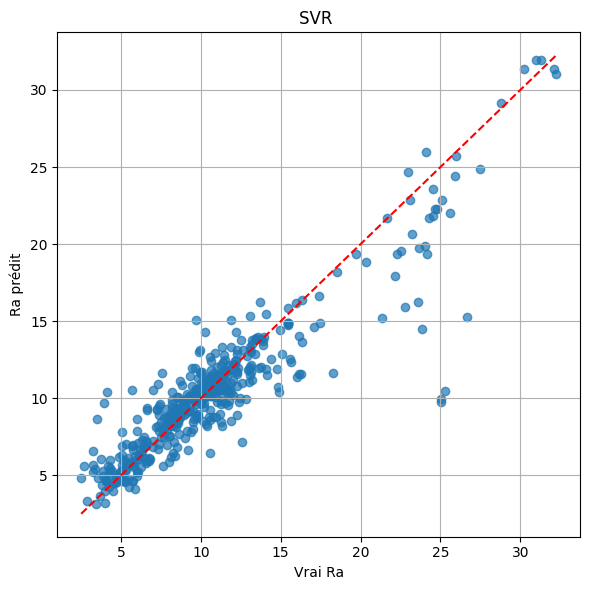

In [57]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'C': [0.1,0.5, 1,5,10],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf'],
     
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

svr = SVR()
grid_svr = GridSearchCV(
    svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_svr.fit(X_train, y_train_bc.ravel())
best_svr = grid_svr.best_estimator_


y_pred_bc_svr = best_svr.predict(X_test)
y_pred_svr = inverse_box_cox(y_pred_bc_svr)


rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100

print("\n--- Meilleur SVR trouvé ---")
print(f"Best params: {grid_svr.best_params_}")
print(f"R2: {r2_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")
print(f"MAE: {mae_svr:.4f}")
print(f"MAPE: {mape_svr:.2f}%")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_svr, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Vrai Ra")
plt.ylabel("Ra prédit")
plt.title("SVR ")
plt.grid(True)
plt.tight_layout()
plt.show()


In [61]:
joblib.dump(best_svr, 'models_pvht_anova_gmm1400/best_svr.joblib')

['models_pvht_anova_gmm1400/best_svr.joblib']

In [24]:
import optuna
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
from sklearn.metrics import mean_squared_error
import numpy as np



def objective(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [32, 64, 128, 256]),
        'n_a': trial.suggest_categorical('n_a', [32, 64, 128, 256]),
        'n_steps': trial.suggest_int('n_steps', 3, 10),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-3, log=True),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-4, 1e-2, log=True)),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'scheduler_params': {"step_size":50, "gamma":0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'verbose': 0,
    }
    
    model = TabNetRegressor(**params)
    
    model.fit(
        X_train=X_train,
        y_train=y_train_bc,
        eval_set=[(X_test, y_test_bc)],
        eval_metric=['rmse'],
        patience=30,
        max_epochs=300,
        batch_size=32,
        virtual_batch_size=16,
        num_workers=0
    )
    
    preds = model.predict(X_test)
    score = np.sqrt(mean_squared_error(y_test_bc, preds)) 
    
    return score 


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) 


print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)


[I 2025-05-06 01:57:03,192] A new study created in memory with name: no-name-5a4db102-363c-4aa7-960a-139a3a24773f



Early stopping occurred at epoch 219 with best_epoch = 189 and best_val_0_rmse = 0.5641


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 02:03:19,275] Trial 0 finished with value: 0.5640999580049905 and parameters: {'n_d': 256, 'n_a': 64, 'n_steps': 4, 'gamma': 1.709958466022447, 'lambda_sparse': 0.0009419236798595237, 'lr': 0.009073027134925348, 'mask_type': 'entmax'}. Best is trial 0 with value: 0.5640999580049905.



Early stopping occurred at epoch 121 with best_epoch = 91 and best_val_0_rmse = 0.9464


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 02:09:47,699] Trial 1 finished with value: 0.9463993440437063 and parameters: {'n_d': 64, 'n_a': 256, 'n_steps': 9, 'gamma': 1.490136683845032, 'lambda_sparse': 0.000295834226117456, 'lr': 0.005560659593038546, 'mask_type': 'sparsemax'}. Best is trial 0 with value: 0.5640999580049905.


...


Early stopping occurred at epoch 94 with best_epoch = 64 and best_val_0_rmse = 1.00678


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 06:27:53,649] Trial 48 finished with value: 1.0067837176104355 and parameters: {'n_d': 128, 'n_a': 128, 'n_steps': 10, 'gamma': 1.7055329647142397, 'lambda_sparse': 1.3052158333123488e-05, 'lr': 0.007824914593779188, 'mask_type': 'entmax'}. Best is trial 30 with value: 0.5098797020712103.



Early stopping occurred at epoch 217 with best_epoch = 187 and best_val_0_rmse = 0.89887


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-05-06 06:45:38,168] Trial 49 finished with value: 0.8988718853728836 and parameters: {'n_d': 256, 'n_a': 256, 'n_steps': 7, 'gamma': 1.7975078701433798, 'lambda_sparse': 1.0671310244454109e-07, 'lr': 0.0005775264049498258, 'mask_type': 'entmax'}. Best is trial 30 with value: 0.5098797020712103.


Best trial:
FrozenTrial(number=30, state=TrialState.COMPLETE, values=[0.5098797020712103], datetime_start=datetime.datetime(2025, 5, 6, 4, 11, 48, 140325), datetime_complete=datetime.datetime(2025, 5, 6, 4, 18, 38, 598238), params={'n_d': 128, 'n_a': 256, 'n_steps': 3, 'gamma': 1.1213952129294609, 'lambda_sparse': 2.4142560880362066e-05, 'lr': 0.009432076934896767, 'mask_type': 'entmax'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_d': CategoricalDistribution(choices=(32, 64, 128, 256)), 'n_a': CategoricalDistribution(choices=(32, 64, 128, 256)), 'n_steps': IntDistribution(high=10, log=False, low=3, step=1), 'gamma': FloatDistribution(high=2.0, log=False, low=1.0, step=None), 'lambda_sparse': FloatDistribution(high=0.001, log=True, low=1e-07, step=None), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'mask_type': CategoricalDistribution(choices=('sparsemax', 'entmax'))}, trial_id=30, value=None)
Best params:
{'n_d': 128, 'n_a': 256, '

In [58]:
tabnet_model = TabNetRegressor(
    n_d=256,
    n_a=256,
    n_steps=3,
    gamma=1.1213952129294609,
    lambda_sparse=2.4142560880362066e-05,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.009432076934896767),
    mask_type='entmax'
)


tabnet_model.fit(
    X_train,
    y_train_bc,
    eval_set=[(X_test, y_test_bc)],
    eval_metric=['rmse'],
    patience=30,
    max_epochs=300,
    batch_size=32,
    virtual_batch_size=16,
    num_workers=0
)

y_pred_tabnet_bc = tabnet_model.predict(X_test)
y_pred_tabnet = inverse_box_cox(y_pred_tabnet_bc)


r2_tabnet = r2_score(y_test, y_pred_tabnet)
rmse_tabnet = np.sqrt(mean_squared_error(y_test, y_pred_tabnet))
mae_tabnet = mean_absolute_error(y_test, y_pred_tabnet)
mape_tabnet = np.mean(np.abs((y_test - y_pred_tabnet) / y_test)) * 100

print(f"R2: {r2_tabnet:.4f}")
print(f"RMSE: {rmse_tabnet:.4f}")
print(f"MAE: {mae_tabnet:.4f}")
print(f"MAPE: {mape_tabnet:.4f}")


c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 13.24352| val_0_rmse: 2.93369 |  0:00:03s
epoch 1  | loss: 2.74782 | val_0_rmse: 1.42549 |  0:00:06s
epoch 2  | loss: 1.87106 | val_0_rmse: 1.42206 |  0:00:09s
epoch 3  | loss: 1.47062 | val_0_rmse: 1.22815 |  0:00:12s
epoch 4  | loss: 1.48299 | val_0_rmse: 1.29826 |  0:00:14s
epoch 5  | loss: 1.2097  | val_0_rmse: 1.26868 |  0:00:17s
epoch 6  | loss: 1.16518 | val_0_rmse: 1.00568 |  0:00:19s
epoch 7  | loss: 1.20414 | val_0_rmse: 1.01404 |  0:00:22s
epoch 8  | loss: 1.05984 | val_0_rmse: 1.14035 |  0:00:24s
epoch 9  | loss: 1.00086 | val_0_rmse: 1.05203 |  0:00:27s
epoch 10 | loss: 1.07606 | val_0_rmse: 1.24473 |  0:00:29s
epoch 11 | loss: 1.02522 | val_0_rmse: 1.17009 |  0:00:32s
epoch 12 | loss: 1.00895 | val_0_rmse: 1.03241 |  0:00:34s
epoch 13 | loss: 0.95431 | val_0_rmse: 1.06563 |  0:00:37s
epoch 14 | loss: 0.99766 | val_0_rmse: 1.24252 |  0:00:39s
epoch 15 | loss: 1.00064 | val_0_rmse: 1.01187 |  0:00:41s
epoch 16 | loss: 0.96625 | val_0_rmse: 1.38856 |  0:00:4

c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


R2: 0.8833
RMSE: 1.8019
MAE: 1.1883
MAPE: 13.0432


In [63]:
tabnet_model.save_model('models_pvht_anova_gmm1400/tabnet_model.zip')

Successfully saved model at models_pvht_anova_gmm1400/tabnet_model.zip.zip


'models_pvht_anova_gmm1400/tabnet_model.zip.zip'

In [59]:
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}


grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train_bc.ravel())


best_tree = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)


y_pred_bc_tree = best_tree.predict(X_test)
y_pred_tree = inverse_box_cox(y_pred_bc_tree)




rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
mape_tree = np.mean(np.abs((y_test - y_pred_tree) / y_test)) * 100

print("\n--- Decision Tree ---")
print(f"R2: {r2_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"MAE: {mae_tree:.4f}")
print(f"MAPE: {mape_tree:.2f}%")




Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best hyperparameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8}

--- Decision Tree ---
R2: 0.7586
RMSE: 2.5912
MAE: 1.4958
MAPE: 56.16%


In [62]:
joblib.dump(best_tree, 'models_pvht_anova_gmm1400/tree.joblib')

['models_pvht_anova_gmm1400/tree.joblib']

In [26]:
from sklearn.linear_model import BayesianRidge


bayes = BayesianRidge(alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6)

bayes.fit(X_train, y_train_bc.ravel())
y_pred_bc_bayes = bayes.predict(X_test)
y_pred_bayes = inverse_box_cox(y_pred_bc_bayes)


rmse_bayes = np.sqrt(mean_squared_error(y_test, y_pred_bayes))
mae_bayes = mean_absolute_error(y_test, y_pred_bayes)
r2_bayes = r2_score(y_test, y_pred_bayes)
mape_bayes = np.mean(np.abs((y_test - y_pred_bayes) / y_test)) * 100

print("\n--- Bayesian Ridge ---")
print(f"R2: {r2_bayes:.4f}")
print(f"RMSE: {rmse_bayes:.4f}")
print(f"MAE: {mae_bayes:.4f}")
print(f"MAPE: {mape_bayes:.2f}%")




--- Bayesian Ridge ---
R2: 0.3075
RMSE: 4.3889
MAE: 3.0911
MAPE: 46.52%


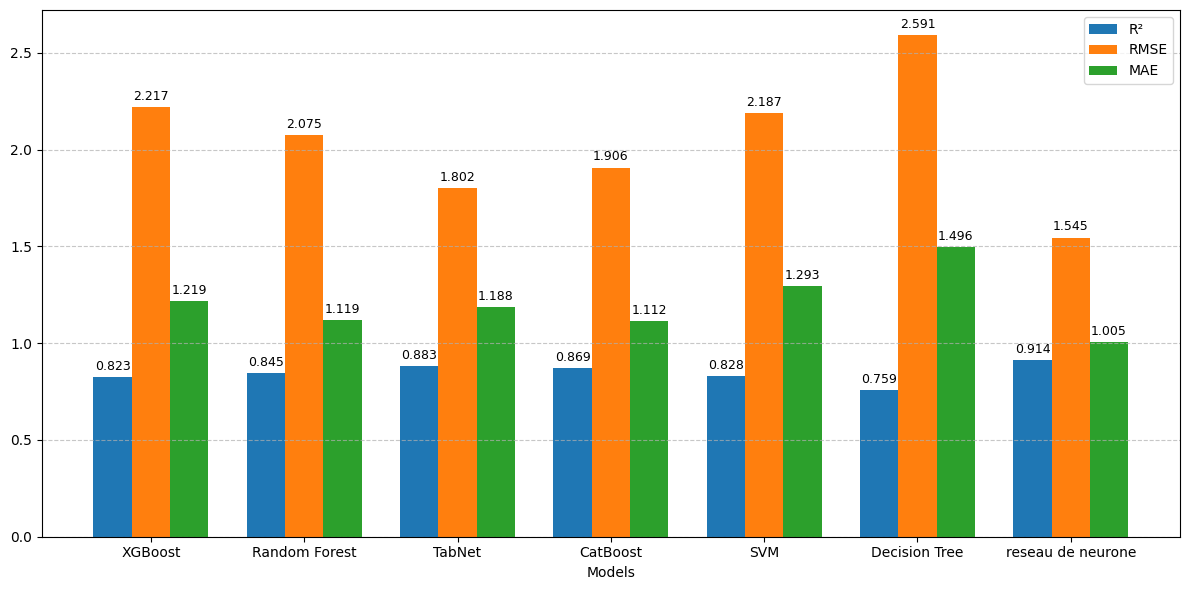

In [60]:

r2_rn = 0.9142
mae_rn = 1.0052
rmse_rn = 1.5448
models = ['XGBoost', 'Random Forest', 'TabNet', 'CatBoost', 'SVM', 'Decision Tree','reseau de neurone']


r2_scores = [r2_xgb, r2_rf, r2_tabnet, r2_cat, r2_svr, r2_tree, r2_rn]
rmse_scores = [rmse_xgb, rmse_rf, rmse_tabnet, rmse_cat, rmse_svr, rmse_tree,rmse_rn]
mae_scores = [mae_xgb, mae_rf, mae_tabnet, mae_cat, mae_svr, mae_tree, mae_rn]


x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, r2_scores, width, label='R²')
bars2 = ax.bar(x, rmse_scores, width, label='RMSE')
bars3 = ax.bar(x + width, mae_scores, width, label='MAE')

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_xlabel('Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()